# Phase 3: marker-gene discovery and cell-type annotation

**Reference clustering:** the selected Leiden solution from `03_eda_clustering.ipynb`, containing **6 clusters**.

This notebook does not treat Leiden numbers as biological labels. It first finds genes enriched in each cluster, compares them with established PBMC markers, and then provides an explicit place to record a human-reviewed cluster-to-cell-type mapping.

The workflow is:

1. Load and validate the six-cluster Leiden result.
2. Display the reference clustering and cluster sizes.
3. Rank marker genes for every Leiden cluster.
4. Filter and export interpretable marker tables.
5. Compare the clusters with known PBMC marker panels.
6. Assign and visualize reviewed cell-type labels.
7. Save a new annotated object without overwriting the clustering input.

## 1. Imports and analysis settings

**What the next cell does:** imports the analysis libraries, sets reproducible display options, and defines thresholds used later. `N_EXPECTED_CLUSTERS = 6` makes the chosen Leiden solution an explicit requirement rather than an assumption.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display

N_EXPECTED_CLUSTERS = 6
N_MARKERS_TO_DISPLAY = 15
MIN_LOG2_FOLD_CHANGE = 0.5
MAX_ADJUSTED_P_VALUE = 0.05

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load the selected Leiden clustering

**What the next cell does:** locates the PBMC3k project from several common notebook launch locations, loads the Phase 2 object, and defines separate output paths for tables, figures, and the final annotated object. It stops with a helpful message if notebook 03 has not yet produced its output.

In [2]:
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend(
        (
            base,
            base / "PBMC3k",
            base / "26-the-backpropagators-analysis" / "PBMC3k",
        )
    )

PROJECT = next(
    (
        path
        for path in candidates
        if (path / "data" / "processed" / "pbmc3k_phase2_clustered.h5ad").is_file()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run 03_eda_clustering.ipynb first; expected "
        "PBMC3k/data/processed/pbmc3k_phase2_clustered.h5ad"
    )

INPUT = PROJECT / "data" / "processed" / "pbmc3k_phase2_clustered.h5ad"
OUTPUT = PROJECT / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad"
TABLES = PROJECT / "results" / "tables"
FIGURES = PROJECT / "results" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT)
print(adata)
print("Input:", INPUT)

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc', 'kmeans', 'leiden_0_2', 'leiden_0_4', 'leiden_0_6', 'leiden_0_8', 'leiden_1_0', 'leiden_1_2', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_std', 'mean', 'std'
    uns: '_leiden_repeat_168', '_leiden_repeat_21', '_leiden_repeat_42', '_leiden_repeat_7', '_leiden_repeat_84', 'kmeans_colors', 'kmeans_model_selection', 'leiden_0_2', 'leiden_0_4', 'leiden_0_6', 'leiden_0_8', 'leiden_1_0', 'leiden_1_2', 'leiden_colors', 'leiden_model_selection', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_normalized'
    obsp: 'connectivities', 'distances'
Input: /Users/Ema/Desktop/cosmos/26-t

### Validate the six-cluster reference

**What the next cell does:** confirms that the object contains Leiden labels, UMAP coordinates, all-gene normalized expression in `.raw`, and exactly six clusters. Marker discovery should use `.raw` because the main matrix was scaled and restricted to highly variable genes for PCA.

In [3]:
required_items = {
    "Leiden labels in adata.obs['leiden']": "leiden" in adata.obs,
    "UMAP coordinates in adata.obsm['X_umap']": "X_umap" in adata.obsm,
    "all-gene normalized expression in adata.raw": adata.raw is not None,
}
display(pd.Series(required_items, name="available").to_frame())

missing = [name for name, present in required_items.items() if not present]
if missing:
    raise ValueError("The Phase 2 object is missing: " + "; ".join(missing))

adata.obs["leiden"] = adata.obs["leiden"].astype("category")
cluster_names = list(adata.obs["leiden"].cat.categories)
if len(cluster_names) != N_EXPECTED_CLUSTERS:
    raise ValueError(
        f"Expected the chosen {N_EXPECTED_CLUSTERS}-cluster Leiden solution, "
        f"but found {len(cluster_names)} clusters: {cluster_names}"
    )

print(f"Validated Leiden reference: {len(cluster_names)} clusters {cluster_names}")
print(f"Cells: {adata.n_obs:,}; genes available for marker testing: {adata.raw.n_vars:,}")

,available
Leiden labels in adata.obs['leiden'],True
UMAP coordinates in adata.obsm['X_umap'],True
all-gene normalized expression in adata.raw,True


Validated Leiden reference: 6 clusters ['0', '1', '2', '3', '4', '5']
Cells: 2,638; genes available for marker testing: 13,656


## 3. Reference view: the selected six-cluster Leiden result

**What the next cell does:** displays the chosen Leiden labels on the existing UMAP and reports cluster sizes. This is the fixed clustering being annotated; UMAP is only a visualization and is not recalculated here.

,cells,percent
leiden,,
0,465,17.6%
1,347,13.2%
2,1140,43.2%
3,525,19.9%
4,150,5.7%
5,11,0.4%


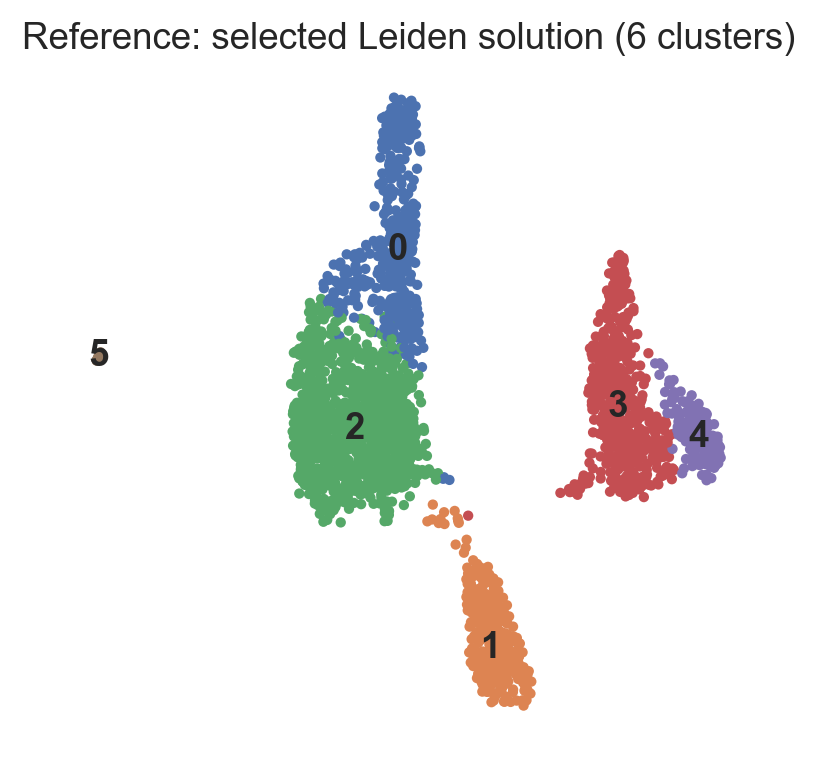

Saved reference figure: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/figures/leiden_6_cluster_reference.png


In [4]:
cluster_sizes = adata.obs["leiden"].value_counts().sort_index().rename("cells").to_frame()
cluster_sizes["percent"] = 100 * cluster_sizes["cells"] / adata.n_obs
display(cluster_sizes.style.format({"percent": "{:.1f}%"}))

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="Reference: selected Leiden solution (6 clusters)",
    save=False,
)

reference_figure = FIGURES / "leiden_6_cluster_reference.png"
axis = sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="Reference: selected Leiden solution (6 clusters)",
    show=False,
)
axis.figure.savefig(reference_figure, dpi=200, bbox_inches="tight")
plt.close(axis.figure)
print("Saved reference figure:", reference_figure)

## 4. Discover genes enriched in each cluster

**What the next cell does:** runs a Wilcoxon rank-sum comparison for each Leiden cluster against all remaining cells. It uses log-normalized all-gene expression from `adata.raw`, applies Benjamini–Hochberg correction, and records the fraction of cells expressing each gene with `pts=True`.

These results are useful for describing clusters. The adjusted p-values should not be interpreted as replicate-level differential-expression evidence because cells from the same sample are not independent biological replicates.

In [5]:
RANK_KEY = "rank_genes_groups_leiden"

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    reference="rest",
    use_raw=True,
    pts=True,
    corr_method="benjamini-hochberg",
    key_added=RANK_KEY,
)

print(f"Marker rankings stored in adata.uns['{RANK_KEY}']")

ranking genes
    finished (0:00:01)
Marker rankings stored in adata.uns['rank_genes_groups_leiden']


### Inspect the strongest marker candidates

**What the next cell does:** plots the top-ranked genes for every cluster. A useful marker is not merely significant: it should have a positive effect size, be detected in a substantial fraction of the target cluster, and be less prevalent elsewhere.

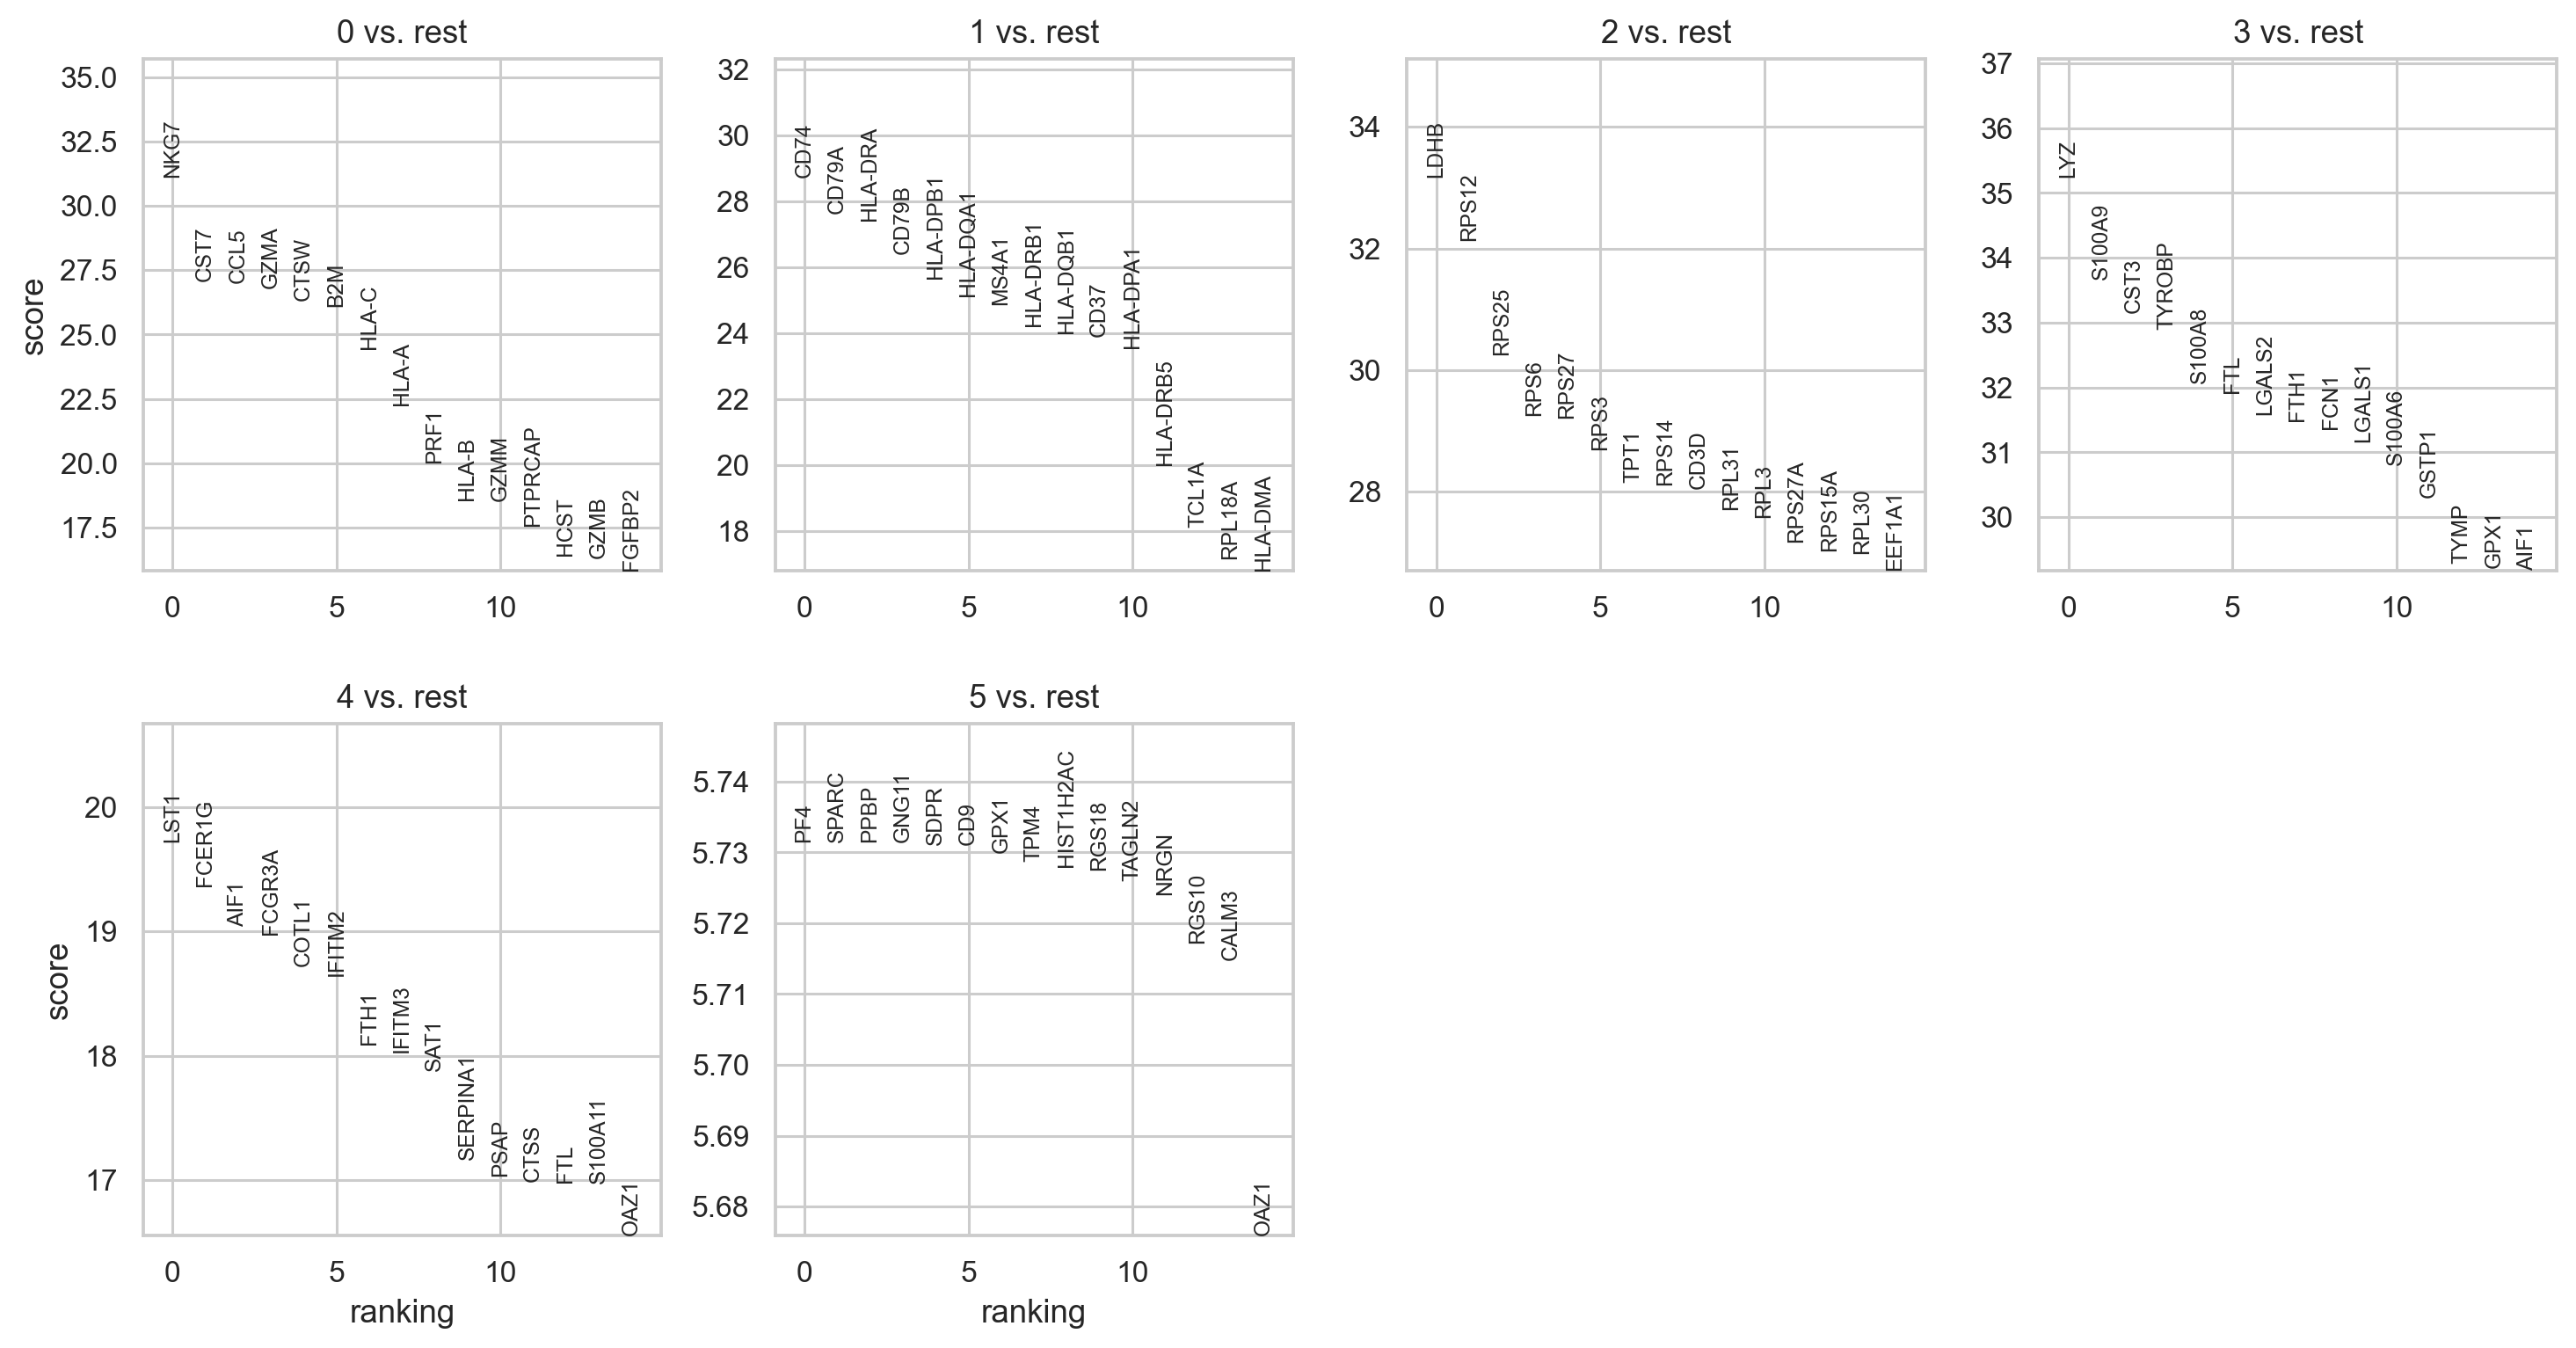

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


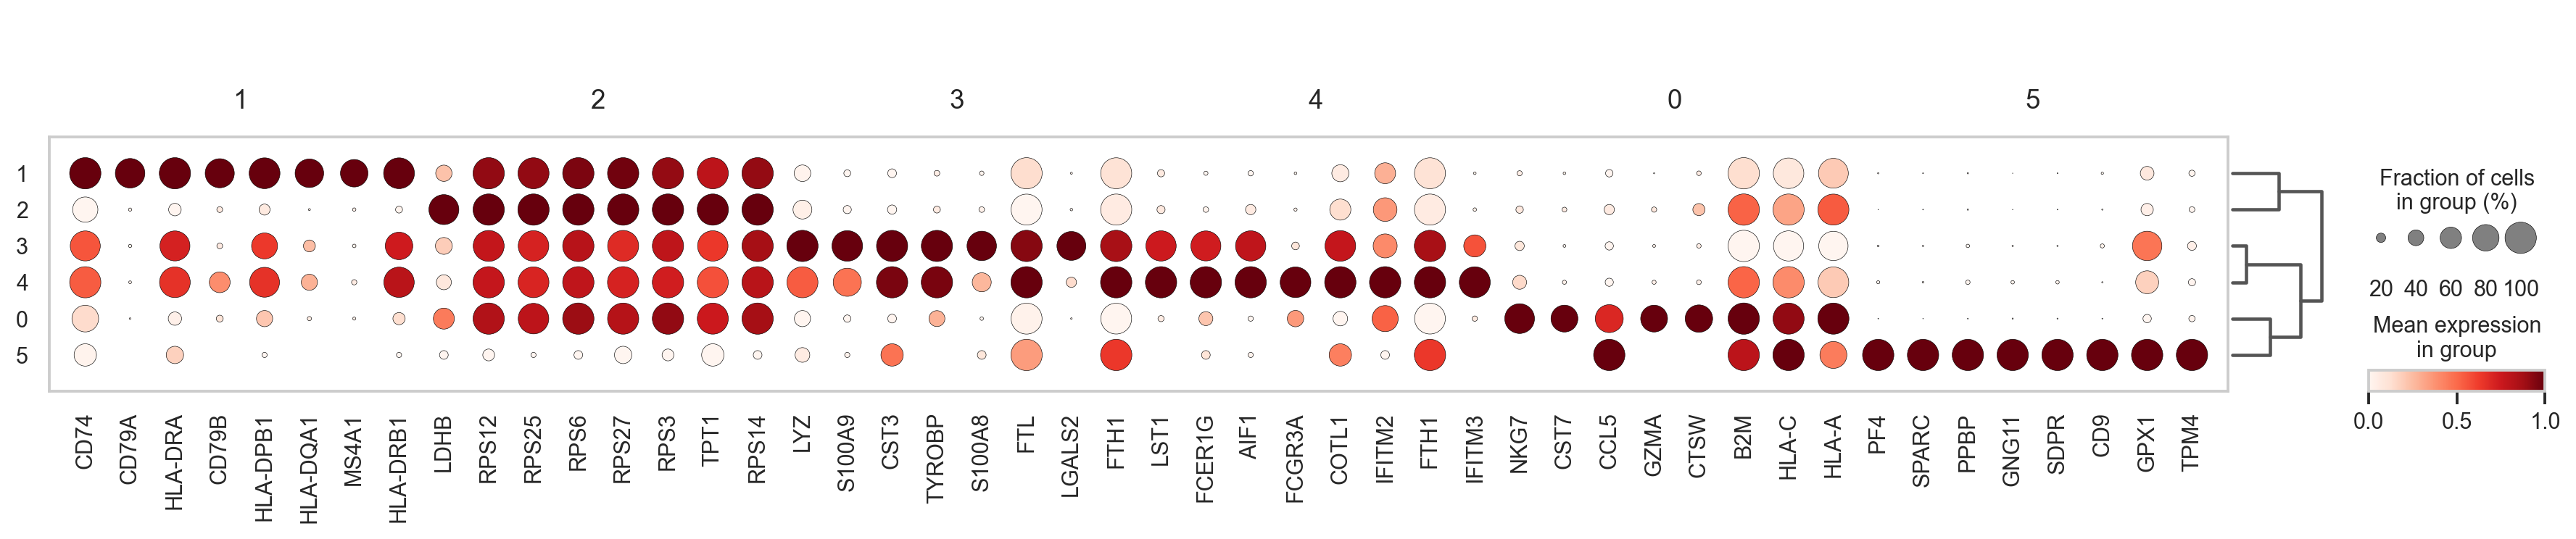

In [6]:
sc.pl.rank_genes_groups(
    adata,
    key=RANK_KEY,
    n_genes=N_MARKERS_TO_DISPLAY,
    sharey=False,
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    key=RANK_KEY,
    n_genes=8,
    groupby="leiden",
    standard_scale="var",
    use_raw=True,
)


## 5. Build and export marker tables

**What the next cell does:** converts the Scanpy result into one tidy table, applies transparent reporting thresholds, adds expression prevalence inside and outside each cluster, and saves both the full and filtered results as CSV files. The thresholds prioritize interpretation; they do not automatically prove cell identity.

In [7]:
all_markers = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=RANK_KEY,
)
all_markers["group"] = all_markers["group"].astype(str)

pts = adata.uns[RANK_KEY]["pts"]
pts_rest = adata.uns[RANK_KEY]["pts_rest"]
prevalence_rows = []
for cluster in cluster_names:
    cluster_string = str(cluster)
    for gene in pts.index:
        prevalence_rows.append({
            "group": cluster_string,
            "names": gene,
            "fraction_expressing_in_cluster": pts.loc[gene, cluster],
            "fraction_expressing_outside_cluster": pts_rest.loc[gene, cluster],
        })

prevalence = pd.DataFrame(prevalence_rows)
all_markers = all_markers.merge(prevalence, on=["group", "names"], how="left")
all_markers["expression_fraction_gap"] = (
    all_markers["fraction_expressing_in_cluster"]
    - all_markers["fraction_expressing_outside_cluster"]
)

filtered_markers = all_markers.loc[
    (all_markers["pvals_adj"] < MAX_ADJUSTED_P_VALUE)
    & (all_markers["logfoldchanges"] > MIN_LOG2_FOLD_CHANGE)
    & (all_markers["fraction_expressing_in_cluster"] >= 0.25)
].copy()
filtered_markers = filtered_markers.sort_values(
    ["group", "scores"], ascending=[True, False]
)

full_marker_path = TABLES / "leiden_6_all_marker_statistics.csv"
filtered_marker_path = TABLES / "leiden_6_filtered_markers.csv"
all_markers.to_csv(full_marker_path, index=False)
filtered_markers.to_csv(filtered_marker_path, index=False)

print("Saved:", full_marker_path)
print("Saved:", filtered_marker_path)
display(filtered_markers.groupby("group", observed=True).head(10))

Saved: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/leiden_6_all_marker_statistics.csv
Saved: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/leiden_6_filtered_markers.csv


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,fraction_expressing_in_cluster,fraction_expressing_outside_cluster,expression_fraction_gap
0,0,NKG7,31.115158,6.977185,1.502269e-212,2.051498e-208,0.935484,0.162448,0.935484,0.162448,0.773036
1,0,CST7,27.060810,6.259276,2.849777e-161,1.945828e-157,0.817204,0.063507,0.817204,0.063507,0.753698
2,0,CCL5,26.985039,5.533813,2.214432e-160,1.008009e-156,0.860215,0.200184,0.860215,0.200184,0.660031
3,0,GZMA,26.780167,6.081553,5.501007e-158,1.878044e-154,0.815054,0.065347,0.815054,0.065347,0.749706
4,0,CTSW,26.325308,4.547554,9.843650e-153,2.688498e-149,0.838710,0.184077,0.838710,0.184077,0.654632
5,0,B2M,26.090483,0.911735,4.675235e-150,1.064084e-146,1.000000,0.999540,1.000000,0.999540,0.000460
6,0,HLA-C,24.431513,1.197987,7.912900e-132,1.543694e-128,0.991398,0.979291,0.991398,0.979291,0.012107
7,0,HLA-A,22.254894,1.198468,1.011335e-109,1.726349e-106,0.993548,0.959503,0.993548,0.959503,0.034045
8,0,PRF1,20.004784,5.452988,5.003435e-89,7.591879e-86,0.619355,0.057064,0.619355,0.057064,0.562291
9,0,HLA-B,18.574938,0.947888,5.126524e-77,7.000782e-74,0.969892,0.943396,0.969892,0.943396,0.026496


### Compact cluster-by-marker summary

**What the next cell does:** creates a review table containing the top marker names for each cluster. This compact summary is convenient when consulting PBMC references or discussing candidate labels with collaborators.

In [8]:
cluster_marker_summary = (
    filtered_markers.groupby("group", observed=True)["names"]
    .apply(lambda genes: ", ".join(genes.head(N_MARKERS_TO_DISPLAY)))
    .rename("top_filtered_markers")
    .to_frame()
    .reindex([str(cluster) for cluster in cluster_names])
)
cluster_marker_summary["cells"] = [
    int(cluster_sizes.loc[cluster, "cells"]) for cluster in cluster_names
]
display(cluster_marker_summary)

summary_path = TABLES / "leiden_6_marker_summary.csv"
cluster_marker_summary.to_csv(summary_path)
print("Saved:", summary_path)

,top_filtered_markers,cells
group,,
0,"NKG7, CST7, CCL5, GZMA, CTSW, B2M, HLA-C, HLA-...",465
1,"CD74, CD79A, HLA-DRA, CD79B, HLA-DPB1, HLA-DQA...",347
2,"LDHB, RPS12, RPS25, RPS6, RPS27, RPS3, TPT1, R...",1140
3,"LYZ, S100A9, CST3, TYROBP, S100A8, FTL, LGALS2...",525
4,"LST1, FCER1G, AIF1, FCGR3A, COTL1, IFITM2, FTH...",150
5,"PF4, SPARC, PPBP, GNG11, SDPR, CD9, GPX1, TPM4...",11


Saved: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/leiden_6_marker_summary.csv


## 6. Compare with established PBMC marker programs

Annotation should use combinations of positive markers, not a single gene. The panel below is intended for **human PBMC3k** and should be changed for another species or tissue.

- T-cell identity: `CD3D`, `CD3E`, and `TRAC`
- Cytotoxic/NK program: `NKG7`, `GNLY`, `KLRD1`, and `CCL5`
- B-cell identity: `MS4A1`, `CD79A`, `CD37`, and `CD74`
- Myeloid identity: `LYZ`, `LST1`, `CTSS`, and `FCER1G`
- Platelet identity: `PPBP` and `PF4`

**What the next cell does:** removes reference genes absent from the dataset, reports any missing genes, and draws a dot plot. Dot size represents the expressing-cell fraction and color represents mean expression.

,markers absent from adata.raw
Naive/helper T,[TRAC]
Cytotoxic T,[]
NK,[]
B,[]
CD14 monocyte,[]
FCGR3A monocyte,[]
Dendritic,[]
Platelet,[]


categories: 0, 1, 2, etc.
var_group_labels: Naive/helper T, Cytotoxic T, NK, etc.


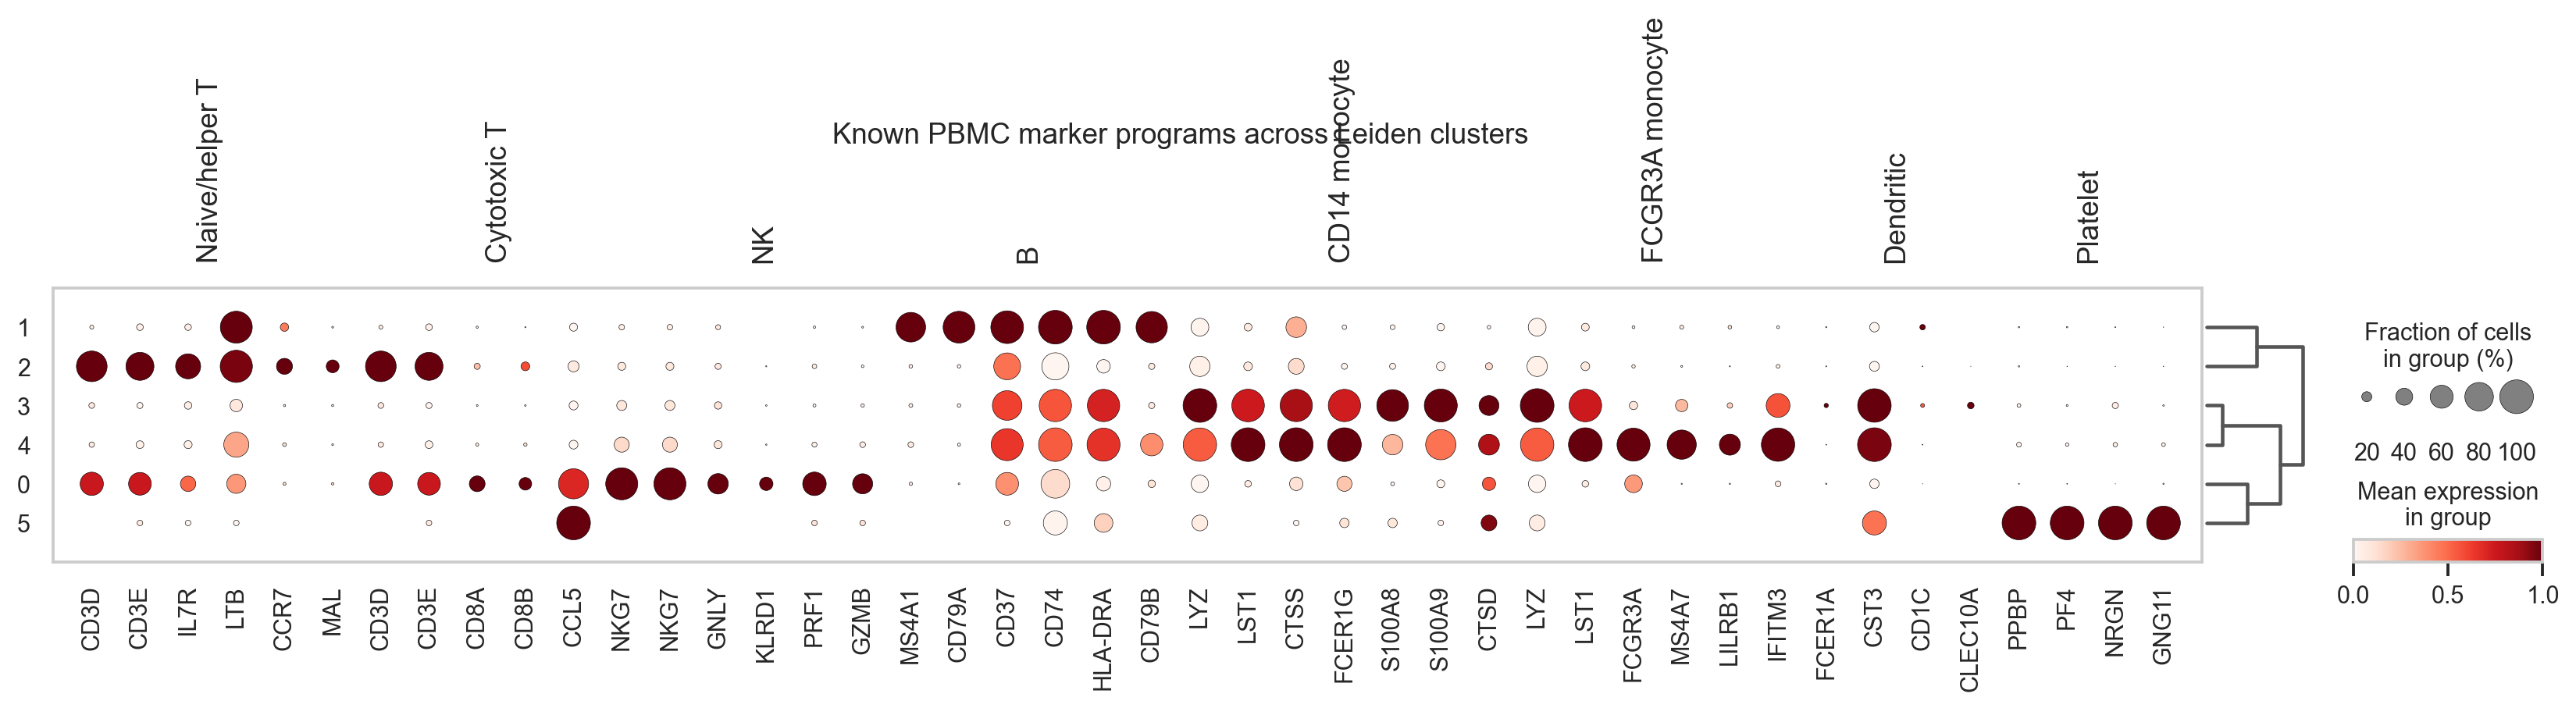

In [9]:
pbmc_marker_panel = {
    "Naive/helper T": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB", "CCR7", "MAL"],
    "Cytotoxic T": ["CD3D", "CD3E", "CD8A", "CD8B", "CCL5", "NKG7"],
    "NK": ["NKG7", "GNLY", "KLRD1", "PRF1", "GZMB"],
    "B": ["MS4A1", "CD79A", "CD37", "CD74", "HLA-DRA", "CD79B"],
    "CD14 monocyte": ["LYZ", "LST1", "CTSS", "FCER1G", "S100A8", "S100A9", "CTSD"],
    "FCGR3A monocyte": ["LYZ", "LST1", "FCGR3A", "MS4A7", "LILRB1", "IFITM3"],
    "Dendritic": ["FCER1A", "CST3", "CD1C", "CLEC10A"],
    "Platelet": ["PPBP", "PF4", "NRGN", "GNG11"],
}

raw_genes = set(adata.raw.var_names)
missing_reference_genes = {
    cell_type: [gene for gene in genes if gene not in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: [gene for gene in genes if gene in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: genes for cell_type, genes in available_pbmc_markers.items() if genes
}

display(pd.Series(missing_reference_genes, name="markers absent from adata.raw").to_frame())
sc.pl.dotplot(
    adata,
    available_pbmc_markers,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    dendrogram=True,
    title="Known PBMC marker programs across Leiden clusters",
)


### Quantify marker-list overlap as supporting evidence

**What the next cell does:** compares the ranked data-derived markers with each reference marker set and displays an overlap score. Higher values indicate more shared markers, but the best numerical match is only a candidate annotation. Closely related populations, shallow sequencing, activation, and doublets can all make the result ambiguous.

,0,1,2,3,4,5
Naive/helper T,0.17,0.17,0.83,0.00,0.00,0.00
Cytotoxic T,0.83,0.00,0.33,0.00,0.00,0.17
NK,1.00,0.00,0.00,0.00,0.00,0.00
B,0.00,1.00,0.00,0.33,0.00,0.00
CD14 monocyte,0.00,0.00,0.00,0.86,0.57,0.00
FCGR3A monocyte,0.17,0.00,0.00,0.50,1.00,0.00
Dendritic,0.00,0.00,0.00,0.25,0.25,0.00
Platelet,0.00,0.00,0.00,0.00,0.00,1.00


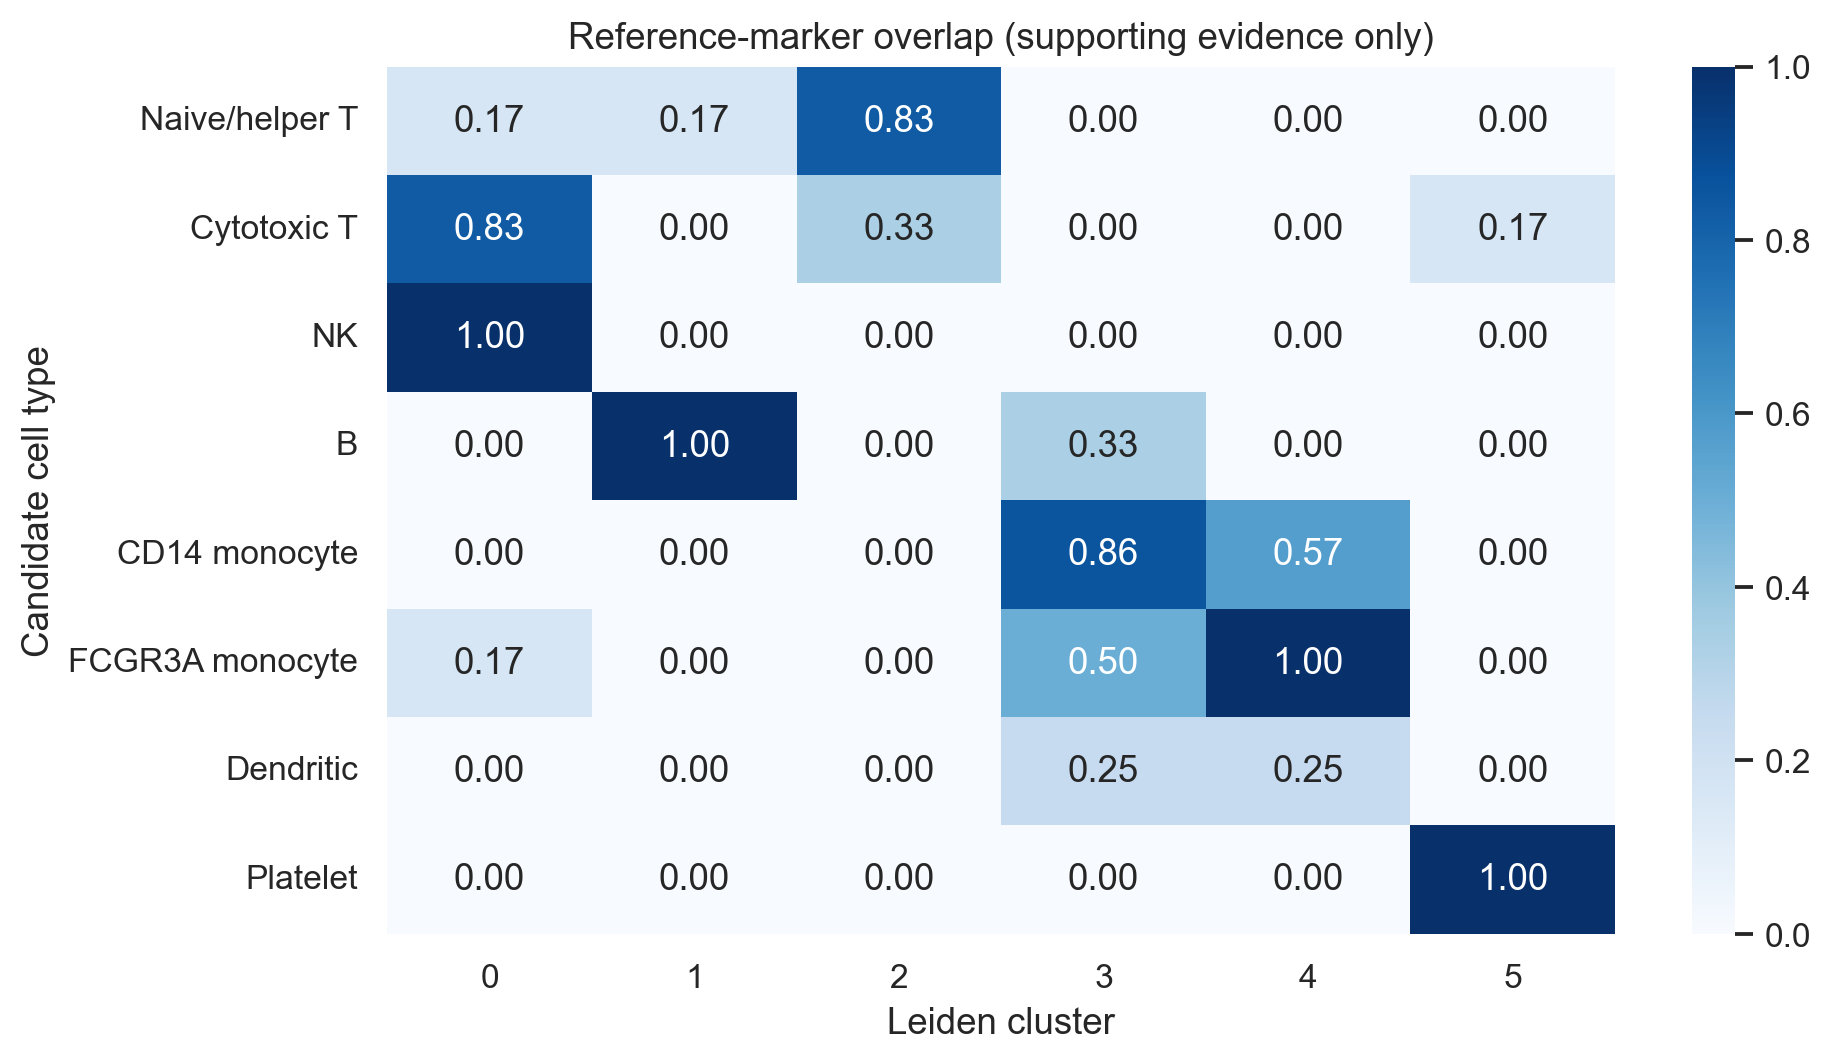

In [10]:
marker_overlap = sc.tl.marker_gene_overlap(
    adata,
    reference_markers=available_pbmc_markers,
    key=RANK_KEY,
    method="overlap_count",
    normalize="reference",
    top_n_markers=100,
    inplace=False,
)
display(marker_overlap.style.background_gradient(cmap="Blues", axis=None).format("{:.2f}"))

plt.figure(figsize=(9, 5))
sns.heatmap(marker_overlap, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Reference-marker overlap (supporting evidence only)")
plt.xlabel("Leiden cluster")
plt.ylabel("Candidate cell type")
plt.tight_layout()
plt.show()

## 7. Human review and annotation decision

For each cluster, review all of the following:

1. Several concordant lineage markers—not one abundant transcript.
2. Marker prevalence inside versus outside the cluster.
3. The known-marker dot plot and overlap table.
4. Cluster size and UMAP location.
5. Possible state or technical programs. Mitochondrial, ribosomal, heat-shock, interferon, and cell-cycle genes may describe condition or quality rather than lineage.
6. Conflicting lineages. Strong markers from two unrelated cell types can indicate doublets.

Use a broad label such as `T cell` or `Myeloid` when the evidence does not support a finer subtype. Use `Ambiguous` instead of forcing a label.

**What the next cell does:** creates an editable decision table with one row per Leiden cluster. Replace every `REVIEW_REQUIRED` value after reviewing the evidence above. Confidence should be `high`, `medium`, or `low`, and notes should record the marker evidence behind the decision.

In [11]:
# EDIT THIS TABLE after reviewing the marker results above.
annotation_review = pd.DataFrame(
    {
        "leiden": [str(cluster) for cluster in cluster_names],
        "cell_type": ["REVIEW_REQUIRED"] * len(cluster_names),
        "confidence": ["REVIEW_REQUIRED"] * len(cluster_names),
        "evidence_notes": [""] * len(cluster_names),
    }
).set_index("leiden")

display(annotation_review)

,cell_type,confidence,evidence_notes
leiden,,,
0,REVIEW_REQUIRED,REVIEW_REQUIRED,
1,REVIEW_REQUIRED,REVIEW_REQUIRED,
2,REVIEW_REQUIRED,REVIEW_REQUIRED,
3,REVIEW_REQUIRED,REVIEW_REQUIRED,
4,REVIEW_REQUIRED,REVIEW_REQUIRED,
5,REVIEW_REQUIRED,REVIEW_REQUIRED,


### Apply reviewed cluster labels to individual cells

**What the next cell does:** checks that every cluster has a reviewed label and valid confidence value. Once the table is complete, it maps the cluster-level decisions to every cell while preserving the original `leiden` column. If review is incomplete, it prints instructions and deliberately does not create misleading annotations.

In [12]:
review_complete = not annotation_review[["cell_type", "confidence"]].eq("REVIEW_REQUIRED").any().any()
valid_confidence = annotation_review["confidence"].isin(["high", "medium", "low"]).all()

if not review_complete:
    print("Annotation has not been applied: replace every REVIEW_REQUIRED entry above.")
elif not valid_confidence:
    print("Annotation has not been applied: confidence must be high, medium, or low.")
else:
    cluster_to_cell_type = annotation_review["cell_type"].to_dict()
    cluster_to_confidence = annotation_review["confidence"].to_dict()
    leiden_strings = adata.obs["leiden"].astype(str)
    adata.obs["cell_type"] = leiden_strings.map(cluster_to_cell_type).astype("category")
    adata.obs["annotation_confidence"] = leiden_strings.map(cluster_to_confidence).astype("category")
    print("Applied reviewed cell-type and confidence labels to every cell.")
    display(pd.crosstab(adata.obs["leiden"], adata.obs["cell_type"]))

Annotation has not been applied: replace every REVIEW_REQUIRED entry above.


### Visual validation of the proposed annotations

**What the next cell does:** when reviewed labels exist, compares the original Leiden numbers with the biological labels on the same UMAP and redraws the known-marker dot plot grouped by cell type. This catches mapping mistakes and labels that contradict their expected marker program.

In [13]:
if "cell_type" not in adata.obs:
    print("Complete and apply annotation_review before running visual validation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sc.pl.umap(
        adata,
        color="leiden",
        legend_loc="on data",
        title="Original Leiden clusters",
        ax=axes[0],
        show=False,
    )
    sc.pl.umap(
        adata,
        color="cell_type",
        legend_loc="right margin",
        title="Reviewed cell-type annotations",
        ax=axes[1],
        show=False,
    )
    plt.tight_layout()
    plt.show()

    sc.pl.dotplot(
        adata,
        available_pbmc_markers,
        groupby="cell_type",
        use_raw=True,
        standard_scale="var",
        title="Marker validation after annotation",
    )

Complete and apply annotation_review before running visual validation.


## 8. Save the reviewed result

**What the next cell does:** saves the completed decision table and a new annotated `.h5ad` object. It does not overwrite `pbmc3k_phase2_clustered.h5ad`. Saving is blocked until every cluster has been reviewed, so an unfinished placeholder cannot silently become a final biological annotation.

In [14]:
if "cell_type" not in adata.obs:
    print("Nothing saved: complete annotation_review and rerun the application cell first.")
else:
    annotation_path = TABLES / "leiden_6_cell_type_annotations.csv"
    annotation_review.to_csv(annotation_path)

    adata.uns["cell_type_annotation"] = {
        "source_cluster_column": "leiden",
        "expected_clusters": N_EXPECTED_CLUSTERS,
        "method": "manual review of Wilcoxon markers, expression prevalence, and known PBMC marker programs",
        "rank_genes_groups_key": RANK_KEY,
    }
    adata.write_h5ad(OUTPUT, compression="gzip")

    print("Saved annotation decisions:", annotation_path)
    print("Saved annotated object:", OUTPUT)
    print(f"Output size: {OUTPUT.stat().st_size / 1024**2:.1f} MB")

Nothing saved: complete annotation_review and rerun the application cell first.


## Interpretation checklist

Before treating the labels as final, confirm that:

- each label is supported by multiple biologically related markers;
- the markers occur in many cells within the target cluster and less often elsewhere;
- no cluster was named mainly from mitochondrial, ribosomal, stress, or cell-cycle genes;
- unrelated lineage markers do not suggest a doublet-rich cluster;
- annotations are consistent across biological samples, if multiple samples are available;
- ambiguous clusters retain broad or explicitly uncertain labels;
- heterogeneous clusters are subsetted and reclustered before assigning overly specific subtypes.